<a href="https://colab.research.google.com/github/Saksh15/INSY-674/blob/main/helmet_detection_yolo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!mkdir -p /content/hard_hat_dataset
!mkdir -p /content/hard_hat_dataset/images
!mkdir -p /content/hard_hat_dataset/annotations

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os, glob

DATASET_PATH = "/content/drive/MyDrive/hard_hat_dataset"
IMAGES_PATH = os.path.join(DATASET_PATH, "images")
XML_PATH = os.path.join(DATASET_PATH, "annotations")

In [3]:
image_files = sorted(
    glob.glob(os.path.join(IMAGES_PATH, "*.jpg")) +
    glob.glob(os.path.join(IMAGES_PATH, "*.jpeg")) +
    glob.glob(os.path.join(IMAGES_PATH, "*.png"))
)
xml_files = sorted(glob.glob(os.path.join(XML_PATH, "*.xml")))

print("Images:", len(image_files))
print("XMLs:", len(xml_files))
print("Sample image:", os.path.basename(image_files[0]) if image_files else "None")
print("Sample xml:", os.path.basename(xml_files[0]) if xml_files else "None")

Images: 5000
XMLs: 5000
Sample image: hard_hat_workers0.png
Sample xml: hard_hat_workers0.xml


In [4]:
import random
import shutil
from pathlib import Path
import xml.etree.ElementTree as ET

OUT_ROOT = "/content/helmet_yolo"

# Create output folders
for split in ["train", "val"]:
    os.makedirs(os.path.join(OUT_ROOT, "images", split), exist_ok=True)
    os.makedirs(os.path.join(OUT_ROOT, "labels", split), exist_ok=True)

# One class only for now
CLASS_MAP = {
    "helmet": 0
}

def convert_box(img_w, img_h, xmin, ymin, xmax, ymax):
    x_center = ((xmin + xmax) / 2.0) / img_w
    y_center = ((ymin + ymax) / 2.0) / img_h
    width = (xmax - xmin) / img_w
    height = (ymax - ymin) / img_h
    return x_center, y_center, width, height

def parse_xml(xml_file):
    tree = ET.parse(xml_file)
    root = tree.getroot()

    filename = root.findtext("filename")
    size = root.find("size")
    img_w = int(size.findtext("width"))
    img_h = int(size.findtext("height"))

    yolo_lines = []

    for obj in root.findall("object"):
        cls_name = obj.findtext("name").strip().lower()

        if cls_name not in CLASS_MAP:
            continue

        bnd = obj.find("bndbox")
        xmin = float(bnd.findtext("xmin"))
        ymin = float(bnd.findtext("ymin"))
        xmax = float(bnd.findtext("xmax"))
        ymax = float(bnd.findtext("ymax"))

        x, y, w, h = convert_box(img_w, img_h, xmin, ymin, xmax, ymax)
        yolo_lines.append(f"{CLASS_MAP[cls_name]} {x:.6f} {y:.6f} {w:.6f} {h:.6f}")

    return filename, yolo_lines

# Shuffle and split
random.seed(42)
random.shuffle(xml_files)

split_idx = int(0.8 * len(xml_files))
train_xmls = xml_files[:split_idx]
val_xmls = xml_files[split_idx:]

def process_split(xml_list, split_name):
    total = 0
    with_labels = 0

    for xml_file in xml_list:
        filename, yolo_lines = parse_xml(xml_file)

        if not filename:
            continue

        src_img = os.path.join(IMAGES_PATH, filename)
        if not os.path.exists(src_img):
            stem = Path(filename).stem
            matches = (
                glob.glob(os.path.join(IMAGES_PATH, stem + ".jpg")) +
                glob.glob(os.path.join(IMAGES_PATH, stem + ".jpeg")) +
                glob.glob(os.path.join(IMAGES_PATH, stem + ".png"))
            )
            if not matches:
                continue
            src_img = matches[0]
            filename = os.path.basename(src_img)

        # Copy image
        dst_img = os.path.join(OUT_ROOT, "images", split_name, filename)
        shutil.copy2(src_img, dst_img)

        # Write label
        label_path = os.path.join(OUT_ROOT, "labels", split_name, Path(filename).stem + ".txt")
        with open(label_path, "w") as f:
            f.write("\n".join(yolo_lines))

        total += 1
        if yolo_lines:
            with_labels += 1

    return total, with_labels

train_total, train_with_labels = process_split(train_xmls, "train")
val_total, val_with_labels = process_split(val_xmls, "val")

print("Train images:", train_total, "| with helmet labels:", train_with_labels)
print("Val images:", val_total, "| with helmet labels:", val_with_labels)

Train images: 4000 | with helmet labels: 3677
Val images: 1000 | with helmet labels: 904


In [5]:
YAML_PATH = os.path.join(OUT_ROOT, "data.yaml")

yaml_text = f"""
path: {OUT_ROOT}
train: images/train
val: images/val

names:
  0: helmet
""".strip()

with open(YAML_PATH, "w") as f:
    f.write(yaml_text)

print(open(YAML_PATH).read())

path: /content/helmet_yolo
train: images/train
val: images/val

names:
  0: helmet


In [6]:
!pip -q install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 36.3 MB/s eta 0:00:00


In [7]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

model.train(
    data=YAML_PATH,
    epochs=10,
    imgsz=640,
    batch=4,
    project="/content/runs",
    name="helmet_detector"
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/helmet_yolo/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, in

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7e1497bfc1d0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [8]:
from ultralytics import YOLO
import glob

best_model = YOLO("/content/runs/helmet_detector/weights/best.pt")

sample_val_image = sorted(glob.glob(os.path.join(OUT_ROOT, "images", "val", "*")))[0]

best_model.predict(
    source=sample_val_image,
    conf=0.25,
    save=True
)

print("Done:", sample_val_image)


image 1/1 /content/helmet_yolo/images/val/hard_hat_workers100.png: 640x640 6 helmets, 7.6ms
Speed: 6.4ms preprocess, 7.6ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict
Done: /content/helmet_yolo/images/val/hard_hat_workers100.png


In [10]:
import os

print(os.listdir("/content/runs/detect"))

['predict']


In [11]:
print(os.listdir("/content/runs/detect/predict"))

['hard_hat_workers100.jpg']


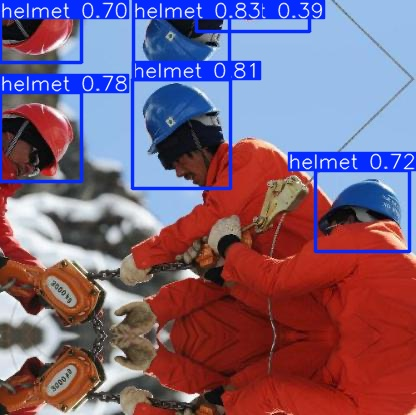

In [12]:
from IPython.display import Image, display

display(Image("/content/runs/detect/predict/hard_hat_workers100.jpg"))